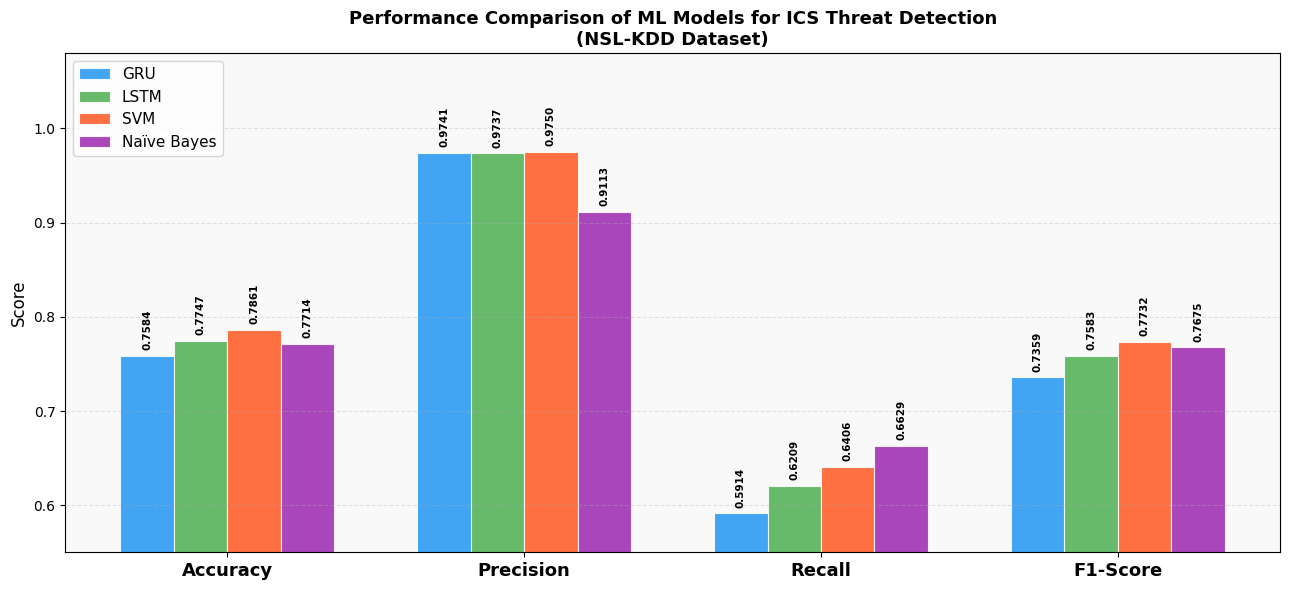

Plot 1 saved.


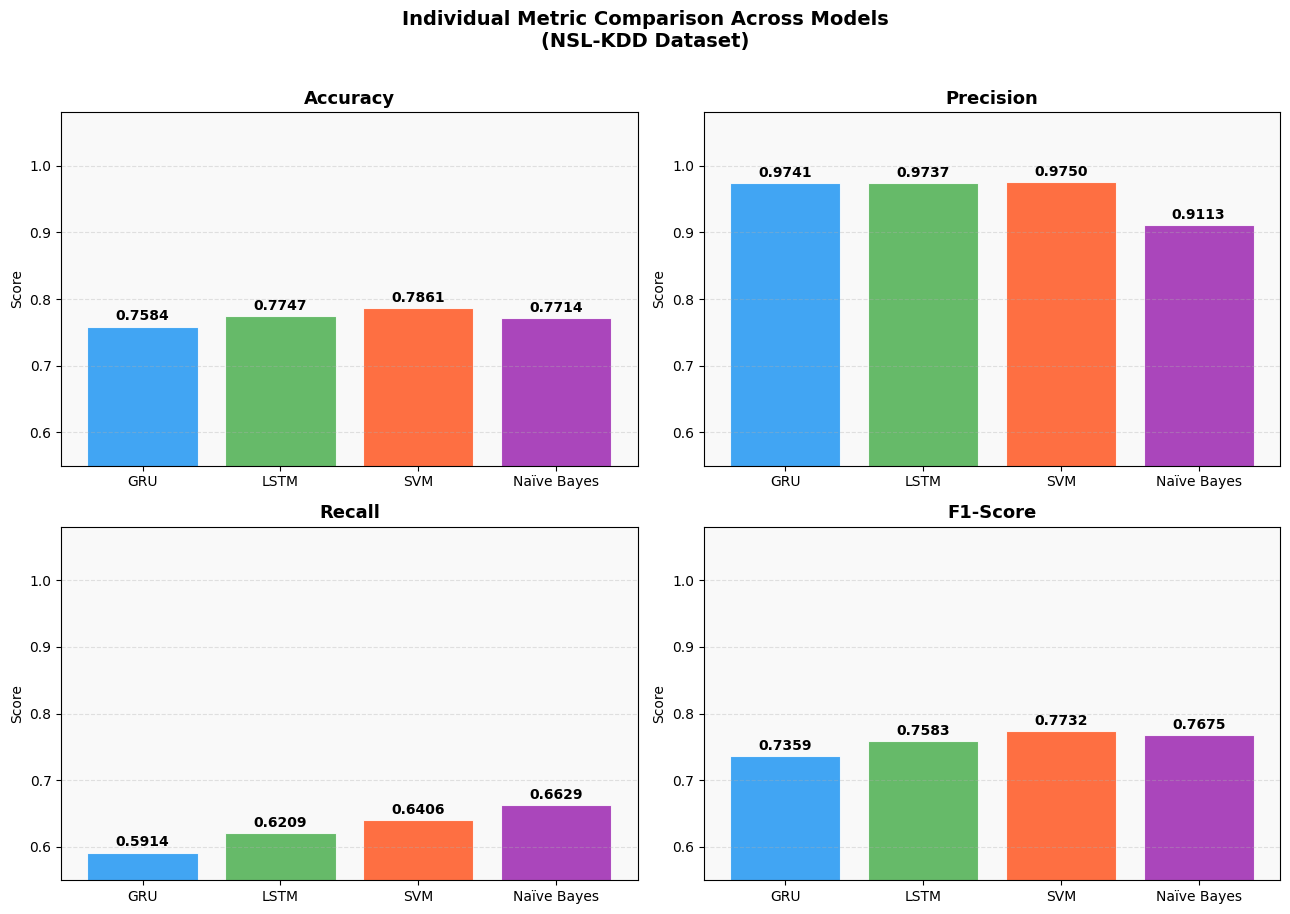

Plot 2 saved.


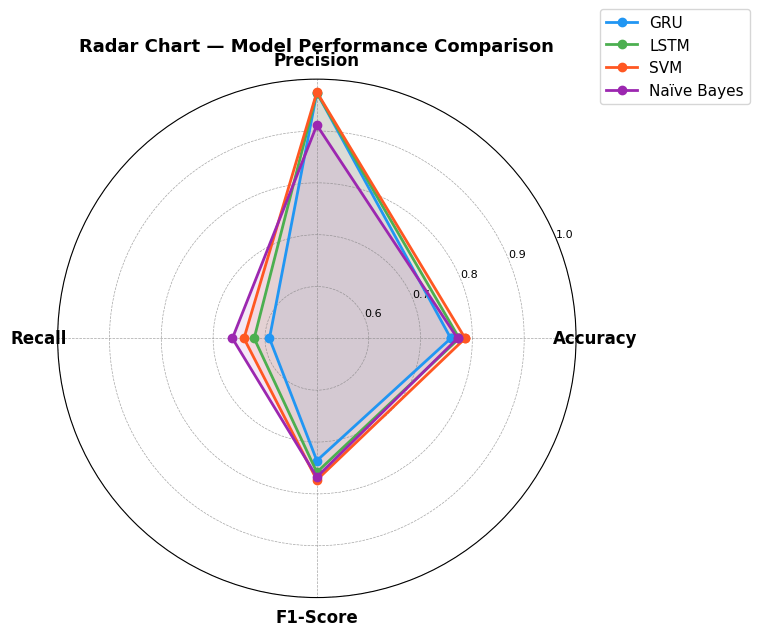

Plot 3 saved.


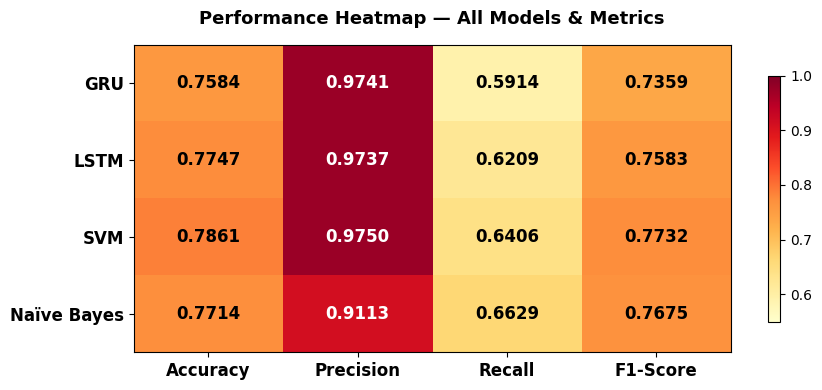

Plot 4 saved.


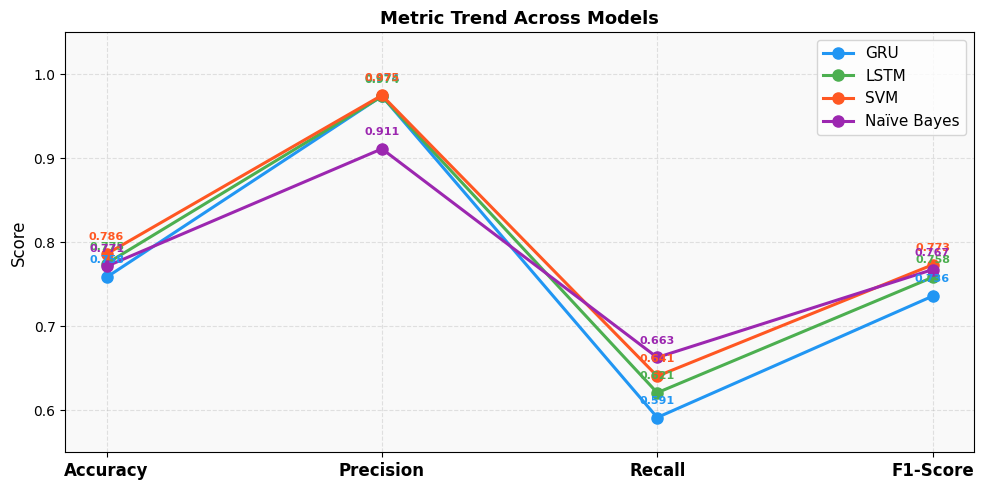

Plot 5 saved.

✅ All 5 plots saved!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─── Your actual results ─────────────────────────────────────────
results = {
    'GRU':         {'Accuracy': 0.7584, 'Precision': 0.9741, 'Recall': 0.5914, 'F1-Score': 0.7359},
    'LSTM':        {'Accuracy': 0.7747, 'Precision': 0.9737, 'Recall': 0.6209, 'F1-Score': 0.7583},
    'SVM':         {'Accuracy': 0.7861, 'Precision': 0.9750, 'Recall': 0.6406, 'F1-Score': 0.7732},
    'Naïve Bayes': {'Accuracy': 0.7714, 'Precision': 0.9113, 'Recall': 0.6629, 'F1-Score': 0.7675},
}

models  = list(results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

# ════════════════════════════════════════════════
# PLOT 1: Grouped Bar Chart (main comparison)
# ════════════════════════════════════════════════
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results[model][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.006,
                f'{v:.4f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold', rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=13, fontweight='bold')
ax.set_ylim(0.55, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison of ML Models for ICS Threat Detection\n(NSL-KDD Dataset)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('plot1_grouped_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("Plot 1 saved.")

# ════════════════════════════════════════════════
# PLOT 2: Individual metric bars (4 subplots)
# ════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    vals = [results[m][metric] for m in models]
    bars = axes[idx].bar(models, vals, color=colors, alpha=0.85,
                         edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.005,
                       f'{v:.4f}', ha='center', va='bottom',
                       fontsize=10, fontweight='bold')
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylim(0.55, 1.08)
    axes[idx].set_ylabel('Score', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.35, linestyle='--')
    axes[idx].set_facecolor('#f9f9f9')
    axes[idx].tick_params(axis='x', labelsize=10)

fig.suptitle('Individual Metric Comparison Across Models\n(NSL-KDD Dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot2_individual_metrics.png', dpi=200, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")

# ════════════════════════════════════════════════
# PLOT 3: Radar / Spider Chart
# ════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch

categories = metrics + [metrics[0]]  # close the loop
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model, color in zip(models, colors):
    vals = [results[model][m] for m in metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], fontsize=8)
ax.set_title('Radar Chart — Model Performance Comparison',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('plot3_radar.png', dpi=200, bbox_inches='tight')
plt.show()
print("Plot 3 saved.")

# ════════════════════════════════════════════════
# PLOT 4: Heatmap Table
# ════════════════════════════════════════════════
data_matrix = np.array([
    [results[m][met] for met in metrics] for m in models
])

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(data_matrix, cmap='YlOrRd', aspect='auto',
               vmin=0.55, vmax=1.0)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=12, fontweight='bold')

for i in range(len(models)):
    for j in range(len(metrics)):
        val = data_matrix[i, j]
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if val > 0.85 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Performance Heatmap — All Models & Metrics',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Plot 4 saved.")

# ════════════════════════════════════════════════
# PLOT 5: Line Plot (trend across metrics)
# ════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(metrics))

for model, color in zip(models, colors):
    vals = [results[model][m] for m in metrics]
    ax.plot(x_pos, vals, 'o-', linewidth=2.2, markersize=8,
            label=model, color=color)
    for xi, v in zip(x_pos, vals):
        ax.annotate(f'{v:.3f}', (xi, v),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0.55, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metric Trend Across Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.35, linestyle='--')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('plot5_line.png', dpi=200, bbox_inches='tight')
plt.show()
print("Plot 5 saved.")

print("\n✅ All 5 plots saved!")

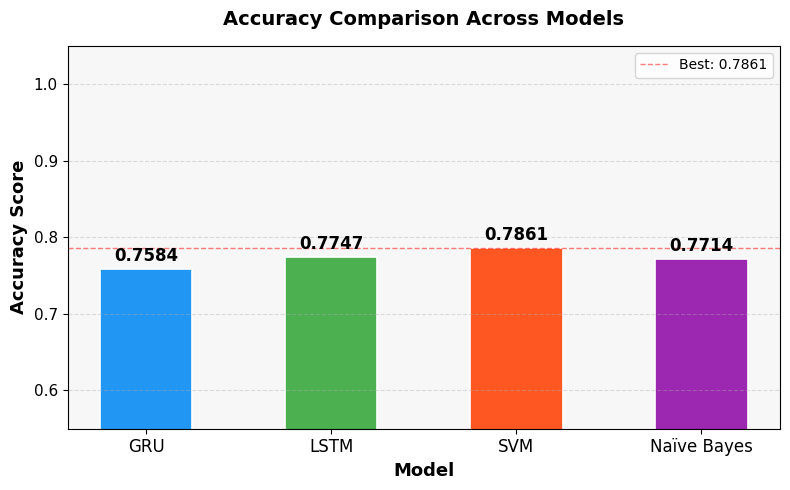

✅ Saved: accuracy_comparison.png


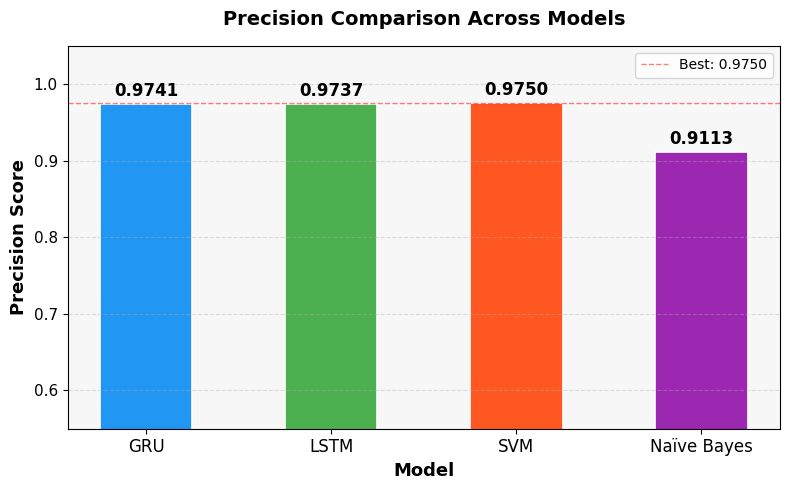

✅ Saved: precision_comparison.png


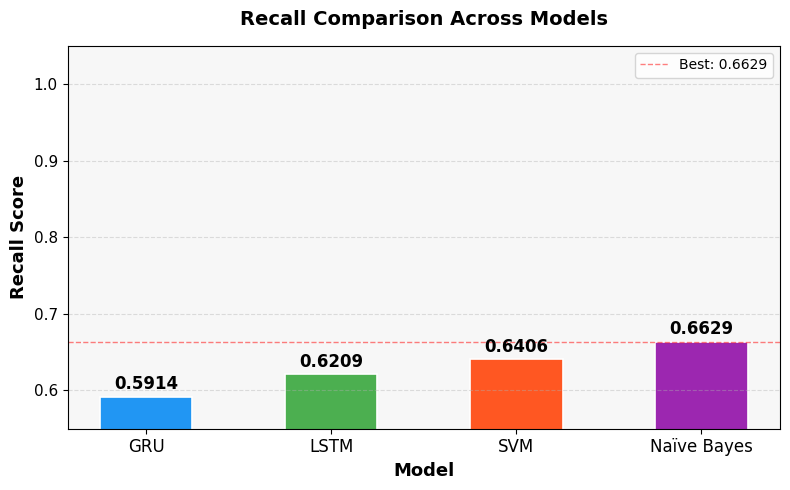

✅ Saved: recall_comparison.png


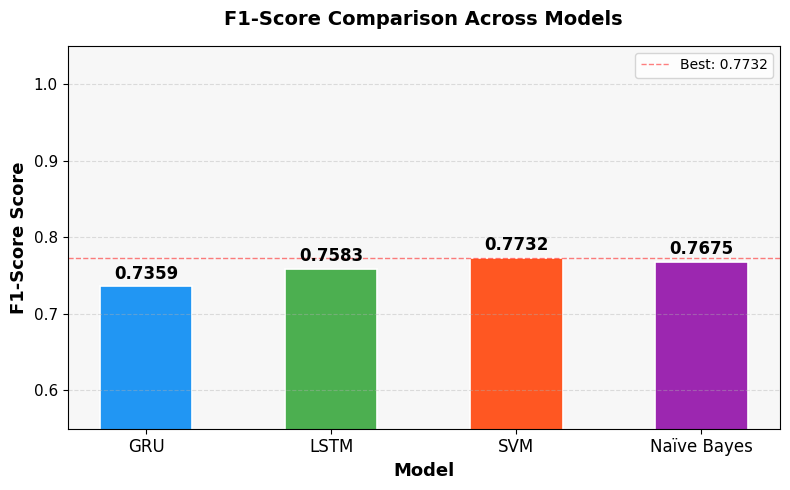

✅ Saved: f1_score_comparison.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Results ────────────────────────────────────────────────────
models = ['GRU', 'LSTM', 'SVM', 'Naïve Bayes']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

data = {
    'Accuracy':  [0.7584, 0.7747, 0.7861, 0.7714],
    'Precision': [0.9741, 0.9737, 0.9750, 0.9113],
    'Recall':    [0.5914, 0.6209, 0.6406, 0.6629],
    'F1-Score':  [0.7359, 0.7583, 0.7732, 0.7675],
}

for metric, values in data.items():
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(models, values, color=colors,
                  width=0.5, edgecolor='white', linewidth=1.2)

    # Value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    # Formatting
    ax.set_ylim(0.55, 1.05)
    ax.set_ylabel(metric + ' Score', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13, fontweight='bold')
    ax.set_title(f'{metric} Comparison Across Models',
                 fontsize=14, fontweight='bold', pad=15)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.set_facecolor('#f7f7f7')
    fig.patch.set_facecolor('white')

    # Add a horizontal reference line at the best value
    best = max(values)
    ax.axhline(y=best, color='red', linestyle='--',
               linewidth=1, alpha=0.5, label=f'Best: {best:.4f}')
    ax.legend(fontsize=10)

    plt.tight_layout()
    filename = f'{metric.lower().replace("-","_")}_comparison.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")